In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)

In [ ]:
DATA_ROOT = "/Heart_disease_CML/data/tabular/heart_disease_combined_numeric.csv"
df = pd.read_csv(DATA_ROOT)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5081, 12)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0
1,67,1,4,160,286,0,2,108,1,1.5,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5081 entries, 0 to 5080
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5081 non-null   int64  
 1   sex       5081 non-null   int64  
 2   cp        5081 non-null   int64  
 3   trestbps  5081 non-null   int64  
 4   chol      5081 non-null   int64  
 5   fbs       5081 non-null   int64  
 6   restecg   5081 non-null   int64  
 7   thalch    5081 non-null   int64  
 8   exang     5081 non-null   int64  
 9   oldpeak   5081 non-null   float64
 10  slope     5081 non-null   int64  
 11  target    5081 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 476.5 KB


In [4]:
drop_cols = [c for c in ["id", "num", "dataset", "source", "risk_label"] if c in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)
    print(f"Dropped columns: {drop_cols}")

print(f"Final shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts()}")


Final shape: (5081, 12)
Target distribution:
target
1    2633
0    2448
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["target"])
y = df["target"]

X.head(), y.value_counts()


(   age  sex  cp  trestbps  chol  fbs  restecg  thalch  exang  oldpeak  slope
 0   63    1   1       145   233    1        2     150      0      2.3      3
 1   67    1   4       160   286    0        2     108      1      1.5      2
 2   67    1   4       120   229    0        2     129      1      2.6      2
 3   37    1   3       130   250    0        0     187      0      3.5      3
 4   41    0   2       130   204    0        2     172      0      1.4      1,
 target
 1    2633
 0    2448
 Name: count, dtype: int64)

In [6]:
categorical_cols = X.select_dtypes(include=["object", "str"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "str"]).columns.tolist()

categorical_cols, numeric_cols


([],
 ['age',
  'sex',
  'cp',
  'trestbps',
  'chol',
  'fbs',
  'restecg',
  'thalch',
  'exang',
  'oldpeak',
  'slope'])

In [7]:
X = X.fillna(X.median(numeric_only=True))



In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape

((4064, 11), (1017, 11))

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8751229105211407
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       490
           1       0.89      0.87      0.88       527

    accuracy                           0.88      1017
   macro avg       0.87      0.88      0.88      1017
weighted avg       0.88      0.88      0.88      1017



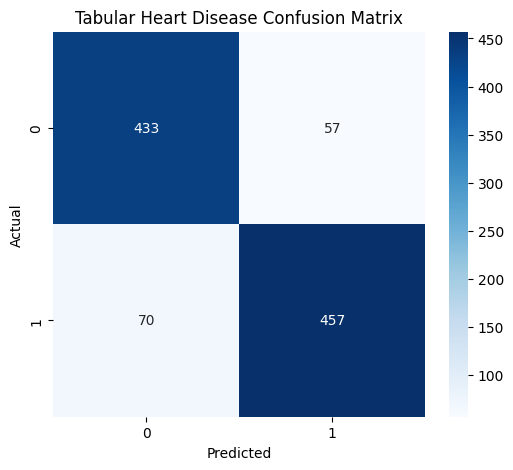

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tabular Heart Disease Confusion Matrix")
plt.show()


In [12]:
import joblib
import os

MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

tab_model_path = os.path.join(MODEL_DIR, "tabular_model.pkl")

joblib.dump(rf_model, tab_model_path)  # change to xgb_model if needed

print("Tabular model saved at:", tab_model_path)


Tabular model saved at: saved_models/tabular_model.pkl
